<a href="https://colab.research.google.com/github/bunga-sky/modul5-cuda/blob/main/modul5-cuda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah 2: Verifikasi GPU di Colab

In [1]:
import subprocess, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

r = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print('=== NVCC Version ===')
print(r.stdout.strip())

r2 = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n=== GPU Info ===')
print(r2.stdout)

os.makedirs('cuda_files', exist_ok=True)
print('Direktori cuda_files siap.')

=== NVCC Version ===
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

=== GPU Info ===
Wed Jun 10 04:50:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |         

Langkah 3: Jalankan CPU Serial

In [2]:
%%writefile cuda_files/vector_add_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N) {
    for (int i = 0; i < N; i++) C[i] = A[i] + B[i];
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i = 0; i < N; i++) {
        A[i] = (float)rand()/RAND_MAX;
        B[i] = (float)rand()/RAND_MAX;
    }
    auto t0 = std::chrono::high_resolution_clock::now();
    vector_add_cpu(A.data(), B.data(), C.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok = true;
    for (int i=0;i<10;i++) if (fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw = (3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,ms,bw,(int)ok);
    return 0;
}

Writing cuda_files/vector_add_cpu.cpp


In [3]:
!g++ -O2 -std=c++11 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu
!./cuda_files/vec_cpu 10000000

N=10000000 TIME_MS=10.5939 BW=11.3273 CORRECT=1


Langkah 4: CPU OpenMP

In [4]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}

Writing cuda_files/vector_add_openmp.cpp


In [5]:
!g++ -O2 -std=c++11 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp
!./cuda_files/vec_omp 10000000 4

N=10000000 THREADS=4 TIME_MS=9.2696 BW=12.9455 CORRECT=1


Langkah 5: CUDA Basic

In [6]:
%%writefile cuda_files/vector_add_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { cudaError_t e=call; if(e!=cudaSuccess){ \
    fprintf(stderr,"CUDA error %s:%d: %s\n",__FILE__,__LINE__,cudaGetErrorString(e)); \
    exit(1);} }

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);
    float *h_A=new float[N], *h_B=new float[N], *h_C=new float[N];
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));
    int blocks = (N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));
    float total = t_htod + t_kernel + t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,blocks,t_htod,t_kernel,t_dtoh,total,(int)ok);
    delete[]h_A;delete[]h_B;delete[]h_C;
    CHECK(cudaFree(d_A));CHECK(cudaFree(d_B));CHECK(cudaFree(d_C));
    return 0;
}

Writing cuda_files/vector_add_cuda.cu


In [7]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_cuda.cu -o cuda_files/vec_cuda
!./cuda_files/vec_cuda 10000000 256

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 BLOCKS=39063 HTOD=17.5112 KERNEL=102.4463 DTOH=25.5455 TOTAL=145.5030 CORRECT=1


Langkah 6: CUDA Pinned Memory

In [8]:
%%writefile cuda_files/vector_add_pinned.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { cudaError_t e=call; if(e!=cudaSuccess){ \
    fprintf(stderr,"CUDA error %s:%d: %s\n",__FILE__,__LINE__,cudaGetErrorString(e)); \
    exit(1);} }

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);
    float *h_A, *h_B, *h_C;
    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));
    int blocks=(N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));
    float total=t_htod+t_kernel+t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
           N,TPB,t_htod,t_kernel,t_dtoh,total,(int)ok);
    CHECK(cudaFreeHost(h_A)); CHECK(cudaFreeHost(h_B)); CHECK(cudaFreeHost(h_C));
    CHECK(cudaFree(d_A)); CHECK(cudaFree(d_B)); CHECK(cudaFree(d_C));
    return 0;
}

Writing cuda_files/vector_add_pinned.cu


In [9]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_pinned.cu -o cuda_files/vec_pinned
!./cuda_files/vec_pinned 10000000 256

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=10000000 TPB=256 HTOD=6.5165 KERNEL=0.6991 DTOH=3.0800 TOTAL=10.2956 CORRECT=1


Langkah 7: Eksperimen Otomatis semua ukuran data

In [10]:
def parse_cpu(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

def parse_cuda(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
results = []

for N in sizes:
    row = {'N': N}
    r = subprocess.run(f'./cuda_files/vec_cpu {N}', shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['cpu_ms'] = float(d.get('TIME_MS',0))

    r = subprocess.run(f'./cuda_files/vec_omp {N} 4', shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['omp_ms'] = float(d.get('TIME_MS',0))

    r = subprocess.run(f'./cuda_files/vec_cuda {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout)
    row['cuda_htod']   = float(d.get('HTOD',0))
    row['cuda_kernel'] = float(d.get('KERNEL',0))
    row['cuda_dtoh']   = float(d.get('DTOH',0))
    row['cuda_total']  = float(d.get('TOTAL',0))

    r = subprocess.run(f'./cuda_files/vec_pinned {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout); row['pinned_total'] = float(d.get('TOTAL',0))

    results.append(row)
    print(f'N={N:>12,}: cpu={row["cpu_ms"]:8.2f}ms  omp={row["omp_ms"]:7.2f}ms  cuda={row["cuda_total"]:7.2f}ms  pinned={row["pinned_total"]:7.2f}ms')

df = pd.DataFrame(results)
print('\n=== Eksperimen selesai ===')

N=       1,000: cpu=    0.00ms  omp=   0.19ms  cuda=   0.31ms  pinned=   0.29ms
N=      10,000: cpu=    0.00ms  omp=   0.18ms  cuda=   0.25ms  pinned=   0.26ms
N=     100,000: cpu=    0.07ms  omp=   0.22ms  cuda=   0.73ms  pinned=   0.33ms
N=   1,000,000: cpu=    0.94ms  omp=   0.88ms  cuda=   5.11ms  pinned=   1.23ms
N=  10,000,000: cpu=   10.49ms  omp=   9.25ms  cuda=  43.92ms  pinned=  10.25ms
N= 100,000,000: cpu=  109.90ms  omp=  90.48ms  cuda= 442.20ms  pinned=  99.89ms

=== Eksperimen selesai ===


In [11]:
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))
print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))

=== Tabel Waktu Eksekusi (ms) ===
        N   cpu_ms  omp_ms  cuda_total  pinned_total
     1000   0.0009  0.1903      0.3078        0.2886
    10000   0.0048  0.1783      0.2539        0.2590
   100000   0.0675  0.2214      0.7258        0.3263
  1000000   0.9396  0.8838      5.1092        1.2257
 10000000  10.4881  9.2498     43.9245       10.2466
100000000 109.9012 90.4812    442.2047       99.8937

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.004729      0.002924        0.003119
    10000     0.026921      0.018905        0.018533
   100000     0.304878      0.093001        0.206865
  1000000     1.063136      0.183904        0.766582
 10000000     1.133873      0.238776        1.023569
100000000     1.214630      0.248530        1.100181


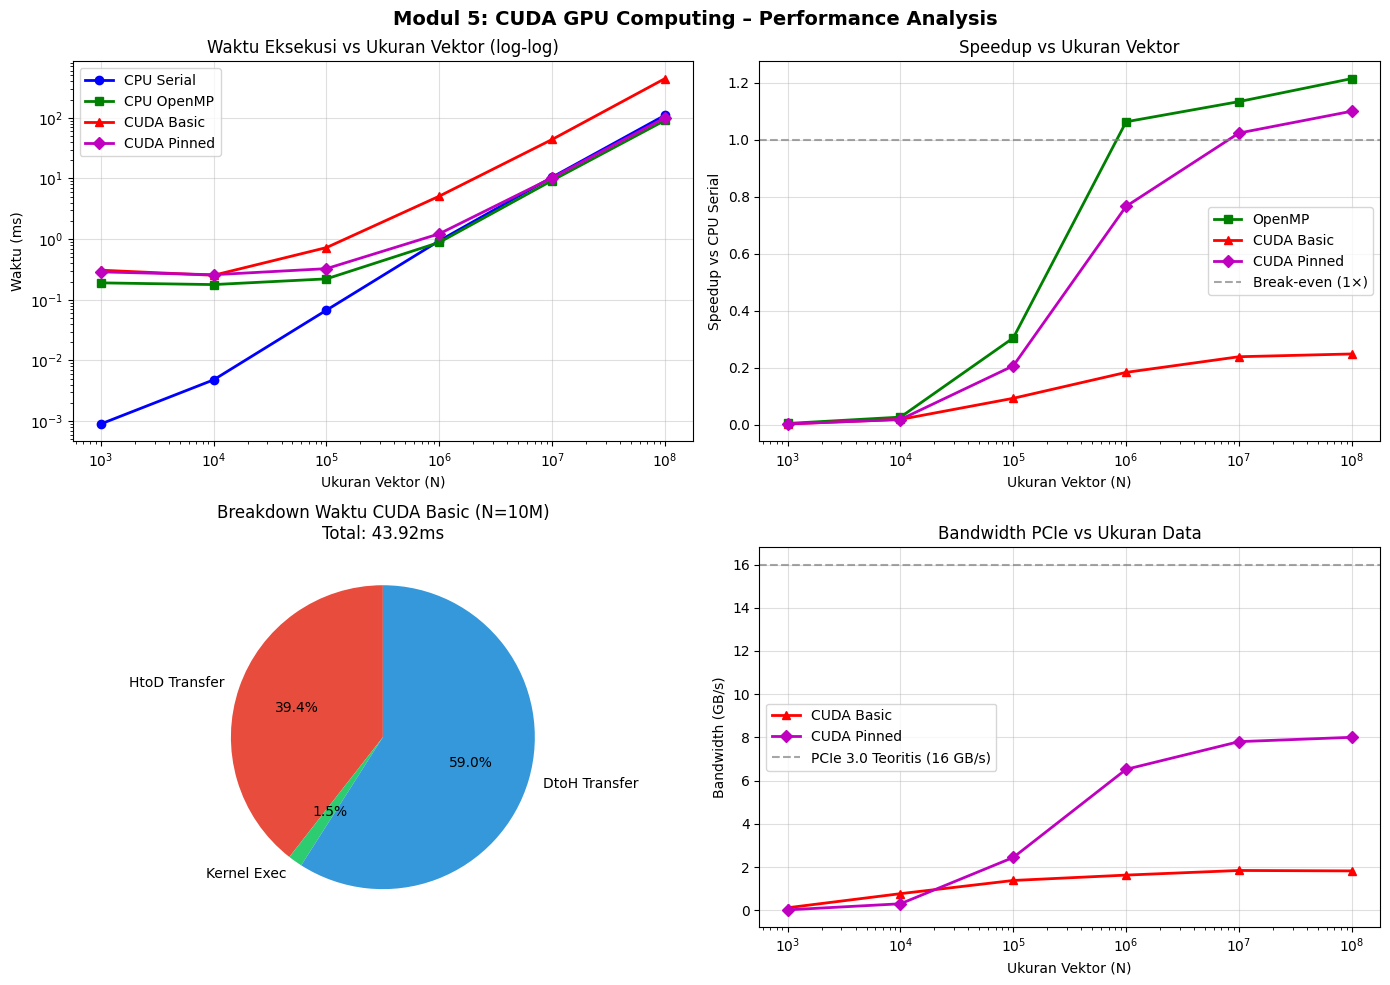

Grafik tersimpan!


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],     'b-o', label='CPU Serial', linewidth=2)
ax.loglog(df['N'], df['omp_ms'],     'g-s', label='CPU OpenMP', linewidth=2)
ax.loglog(df['N'], df['cuda_total'], 'r-^', label='CUDA Basic', linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

ax = axes[1,0]
row10m = df[df['N']==10_000_000].iloc[0]
labels_b = ['HtoD Transfer','Kernel Exec','DtoH Transfer']
vals_b = [row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']]
colors_b = ['#E74C3C','#2ECC71','#3498DB']
ax.pie(vals_b, labels=labels_b, colors=colors_b, autopct='%1.1f%%', startangle=90)
ax.set_title(f'Breakdown Waktu CUDA Basic (N=10M)\nTotal: {row10m["cuda_total"]:.2f}ms')

ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cuda_files/performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan!')

Langkah 8 (Thread per Block)

TPB=   32: kernel=1.1564ms  total=43.8337ms
TPB=   64: kernel=0.6592ms  total=46.2575ms
TPB=  128: kernel=0.6096ms  total=45.5827ms
TPB=  256: kernel=0.6542ms  total=45.0768ms
TPB=  512: kernel=0.6478ms  total=43.7174ms
TPB= 1024: kernel=0.6084ms  total=44.0415ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     1.1564   43.8337
              64  156250     0.6592   46.2575
             128   78125     0.6096   45.5827
             256   39063     0.6542   45.0768
             512   19532     0.6478   43.7174
            1024    9766     0.6084   44.0415


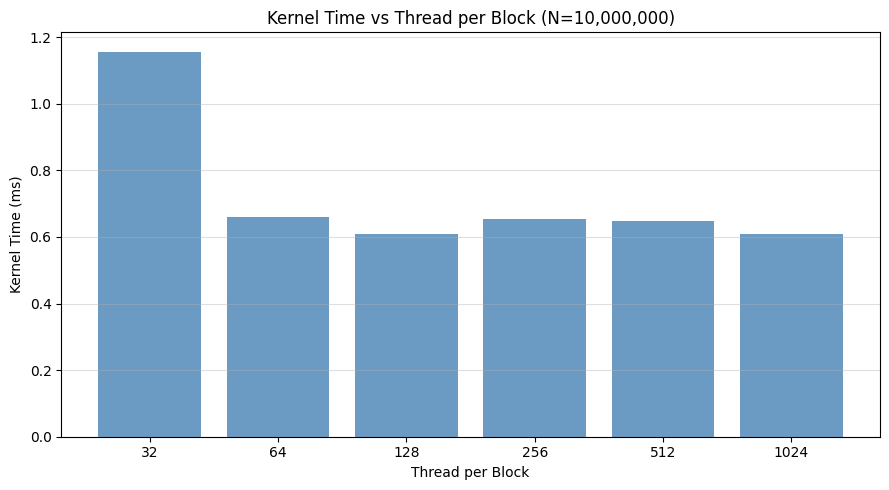

In [13]:
tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'./cuda_files/vec_cuda {N_test} {tpb}',
                       shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL',0)),
        'Total_ms'       : float(d.get('TOTAL',0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cuda_files/tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()